<h4>Astreoids Risk Analysis Dashboard (ARAD) Risk Model Notebook<h4> 
This notebook will be used to test a Decision Tree model.

In [11]:
import os 
import sqlite3
import pandas as pd

In [12]:
db_path = os.path.join("..","astreoid_risk_anaylzed.db")
conn = sqlite3.connect(db_path) 
df = pd.read_sql("SELECT * FROM astreoids WHERE close_date",conn) 

In [13]:
df.head(3)

,close_date,astreoid_name,max_diameter,min_diameter,absoulte_magnitude,min_distance_km,min_distance_au,speed_kmh,potentially_hazardous,sentry_object
0,2026-05-24,(2010 SX11),0.065169,0.029144,24.8,6.167525e+07,0.412274,26751.080414,0,0
1,2026-05-23,(2000 UR16),0.098637,0.044112,23.9,7.445741e+07,0.497717,74366.251824,0,0
2,2026-05-22,(2011 UD256),0.622358,0.278327,19.9,6.209497e+07,0.415079,128183.818181,0,0


In [14]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.model_selection import train_test_split 

In [15]:
X = df.drop(["close_date","astreoid_name","min_distance_km","potentially_hazardous"],axis=1)  
Y = df["potentially_hazardous"] 

In [16]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.3,random_state=22)

0.7192982456140351
0.8383458646616542


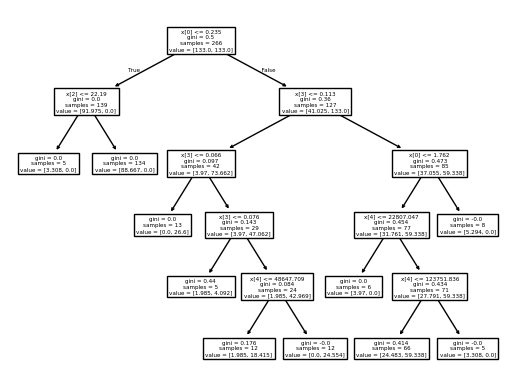

In [17]:
des_tree = DecisionTreeClassifier(max_depth=5,random_state=22,min_samples_leaf=5,class_weight="balanced")
model = des_tree.fit(x_train,y_train) 
predict = model.predict(x_test)
plot_tree(des_tree)
print(model.score(x_test,y_test))
print(model.score(x_train,y_train))

In [18]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80        98
           1       0.33      1.00      0.50        16

    accuracy                           0.72       114
   macro avg       0.67      0.84      0.65       114
weighted avg       0.91      0.72      0.76       114



In [19]:
confusion_matrix(y_test,predict)

array([[66, 32],
       [ 0, 16]])